 # Logistic Regression

`Logistic Regression `    predicts the probability that an instance belongs to a particular class.it is also called the sigmoid function. The sigmoid function maps any real-valued number to a value between 0 and 1.The output of the `sigmoid function `is the probability that the given input belongs to the default class (usually class 1). If the probability is greater than 0.5, we predict class 1; otherwise, class 0.Evaluation metrics: Since it's a classification model, metrics like `accuracy, precision, recall, F1-score, ROC-AUC `are relevant. Choosing the right threshold for classification is important, which can be adjusted based on the problem's needs (e.g., higher recall for medical diagnosis).

 Examples of use cases:

 `Spam detection, customer churn prediction, disease diagnosis, etc`. 

 Logistic Regression can be used for:

1. Binary classification
2.  Multi-class classification
3. One vs rest classification

# Assumptions of Logistic Regression

1. THe dependent variable must be categorical in nature
2. The independent variables must be continuous in nature
3. No outliers
4. No high correlation
5. No multicollinearity

In [13]:
# import libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
# LEt's load simple imputer
from sklearn.impute import SimpleImputer

In [28]:
 # import dataset titnaic datast
df=sns.load_dataset("titanic")
df.head()
 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Pre -processing

In [29]:
# Remove deck column using simple imputer
imputer=SimpleImputer(strategy='mean')
df['age']=imputer.fit_transform(df[['age']])
df['fare']=imputer.fit_transform(df[['fare']])
 #Let's fill embarked column
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0], inplace=True)
# Let's remove deck column
df.drop('deck', axis=1, inplace=True)
df.isnull().sum()



C:\Users\dell\AppData\Local\Temp\ipykernel_5916\3675805742.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_5916\3675805742.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    int64   
 8   class        891 non-null    category
 9   who          891 non-null    int64   
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    int64   
 12  alive        891 non-null    int64   
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(9)
memory usage: 79.4 KB


In [33]:
# Label ENcoding
le=LabelEncoder()

for i in df.columns:
    if df[i].dtype=='object' or df[i].dtype=='category':
        df[i]=le.fit_transform(df[i])
    else:
        pass

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


In [36]:

# select features and target
X=df.drop('survived', axis=1)
y=df['survived']

#  Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# call the model
model=LogisticRegression()
model

LogisticRegression()

In [38]:
# predict the model
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
# Evalauate the model
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
1.0
1.0
1.0
[[105   0]
 [  0  74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



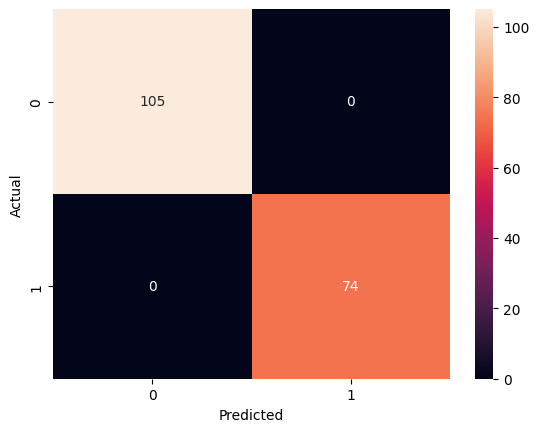

In [42]:
# Plot the confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.xlabel('Predicted')   
plt.ylabel('Actual')
plt.show()